# Amazon Fine Food Reviews

### Import required libraries

In [2]:
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pavan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\pavan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pavan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pavan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\pavan\AppData\Roaming\nltk_data...


## Load Dataset

In [3]:
df=pd.read_csv("Reviews.csv")

In [4]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 313.1 MB


In [6]:
df.shape

(568454, 10)

In [7]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [8]:
#Total Users
df["UserId"].nunique()

256059

In [9]:
#Total Products:
df["ProductId"].nunique()

74258

In [10]:
#Users with more than 50 reviews: 260
(df["UserId"].value_counts()>50).sum()

np.int64(260)

In [11]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
df["Helpfulness_Ratio"] = (
    df["HelpfulnessNumerator"] / df["HelpfulnessDenominator"]
).fillna(0)


In [13]:
df.head(1)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Helpfulness_Ratio
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,1.0


In [14]:
df=df.dropna()

In [15]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
Helpfulness_Ratio         0
dtype: int64

In [16]:
df=df.drop(columns=["Id","UserId","Time","ProfileName","ProductId"])

In [17]:
df

,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text,Helpfulness_Ratio
0,1,1,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,1.0
1,0,0,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0.0
2,1,1,4,"""Delight"" says it all",This is a confection that has been around a fe...,1.0
3,3,3,2,Cough Medicine,If you are looking for the secret ingredient i...,1.0
4,0,0,5,Great taffy,Great taffy at a great price. There was a wid...,0.0
...,...,...,...,...,...,...
568449,0,0,5,Will not do without,Great for sesame chicken..this is a good if no...,0.0
568450,0,0,2,disappointed,I'm disappointed with the flavor. The chocolat...,0.0
568451,2,2,5,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",1.0
568452,1,1,5,Favorite Training and reward treat,These are the BEST treats for training and rew...,1.0


In [18]:
df["Score"].value_counts()

Score
5    363102
4     80654
1     52264
3     42638
2     29743
Name: count, dtype: int64

## Text Cleaning

In [19]:
def clean(doc):
  #doc is a string of text
  #let's define a regex to match special characters and digits
  regex="[^a-zA-Z.]"
  doc=re.sub(regex," ",doc)
  doc=doc.lower()
  #Tokenization
  tokens=nltk.word_tokenize(doc)
  #stop word removal
  stop_words=stopwords.words("english")
  filtered_tokens=[token for token in tokens if token not in stop_words]
  #lemmatization
  lemmatizer=WordNetLemmatizer()
  lemmatized_tokens=[lemmatizer.lemmatize(token) for token in filtered_tokens]
  return " ".join(lemmatized_tokens)

In [ ]:
# #apply text cleaning on text column
df["Text"]=df["Text"].apply(lambda x : clean(x))
df.head()

In [ ]:
#apply text cleaning on summary
df["Summary"]=df["Summary"].apply(lambda x : clean(x))
df.head()

,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text,Helpfulness_Ratio
0,1,1,5,good quality dog food,bought several vitality canned dog food produc...,1.0
1,0,0,1,advertised,product arrived labeled jumbo salted peanut .....,0.0
2,1,1,4,delight say,confection around century . light pillowy citr...,1.0
3,3,3,2,cough medicine,looking secret ingredient robitussin believe f...,1.0
4,0,0,5,great taffy,great taffy great price . wide assortment yumm...,0.0


In [ ]:
df.to_csv("Cleaned_reviwes.csv")

## Reload cleaned data & create the target (`Sentiment`)

In [ ]:
data=pd.read_csv("Cleaned_reviwes.csv")

In [ ]:
data.head()

,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text,Helpfulness_Ratio
0,1,1,5,good quality dog food,bought several vitality canned dog food produc...,1.0
1,0,0,1,advertised,product arrived labeled jumbo salted peanut .....,0.0
2,1,1,4,delight say,confection around century . light pillowy citr...,1.0
3,3,3,2,cough medicine,looking secret ingredient robitussin believe f...,1.0
4,0,0,5,great taffy,great taffy great price . wide assortment yumm...,0.0


In [ ]:
data.shape

(568401, 6)

In [ ]:
# Creating a target variable Sentiment
data["Sentiment"]= data["Score"].apply(lambda x: "Positive" if x>3 else("Negative" if x < 3 else "Neutral"))
data.head()

,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text,Helpfulness_Ratio,Sentiment
0,1,1,5,good quality dog food,bought several vitality canned dog food produc...,1.0,Positive
1,0,0,1,advertised,product arrived labeled jumbo salted peanut .....,0.0,Negative
2,1,1,4,delight say,confection around century . light pillowy citr...,1.0,Positive
3,3,3,2,cough medicine,looking secret ingredient robitussin believe f...,1.0,Negative
4,0,0,5,great taffy,great taffy great price . wide assortment yumm...,0.0,Positive


In [30]:
positive_df = data[data["Sentiment"] == "Positive"]

negative_df = data[data["Sentiment"] == "Negative"]

neutral_df = data[data["Sentiment"] == "Neutral"]

In [35]:
positive_df.head()

,Score,Summary,Text,Sentiment
0,5,good quality dog food,bought several vitality canned dog food produc...,Positive
2,4,delight say,confection around century . light pillowy citr...,Positive
4,5,great taffy,great taffy great price . wide assortment yumm...,Positive
5,4,nice taffy,got wild hair taffy ordered five pound bag . t...,Positive
6,5,great good expensive brand,saltwater taffy great flavor soft chewy . cand...,Positive


In [32]:
negative_df.head()

,Score,Summary,Text,Sentiment
1,1,advertised,product arrived labeled jumbo salted peanut .....,Negative
3,2,cough medicine,looking secret ingredient robitussin believe f...,Negative
12,1,cat fan new food,cat happily eating felidae platinum two year ....,Negative
16,2,poor taste,love eating good watching tv looking movie swe...,Negative
26,1,nasty flavor,candy red flavor . plan chewy . would never buy,Negative


In [33]:
neutral_df.head()

,Score,Summary,Text,Sentiment
45,3,hearty oatmeal,seems little wholesome supermarket brand somew...,Neutral
47,3,mushy,flavor good . however see differce oaker oat b...,Neutral
49,3,stuff,stuff buy big box store . nothing healthy . ca...,Neutral
53,3,as kickin,used spicy food south texas spicy . doubt much...,Neutral
60,3,better price target,watch price . assortment good get gold box pur...,Neutral


In [38]:
print("Positive_df :" ,positive_df.shape)
print("Negative_df :" ,negative_df.shape)
print("Neutral_df :" ,neutral_df.shape)


Positive_df : (443756, 4)
Negative_df : (82007, 4)
Neutral_df : (42638, 4)


## EDA on the labeled data

In [ ]:
from collections import Counter
import re
# function to clean text and extract words
def get_words(text):# convert to lowercase
  text = re.sub(r"[^a-zA-Z\s]", "", text)
  words = text.split()
  return words
all_words = data["Text"].loc[:10000].apply(get_words).sum()
word_counts=Counter(all_words)
print(word_counts.most_common(10))

[('br', 10800), ('like', 4531), ('coffee', 3973), ('taste', 3766), ('flavor', 3537), ('good', 3525), ('product', 3373), ('one', 3215), ('great', 2868), ('love', 2558)]


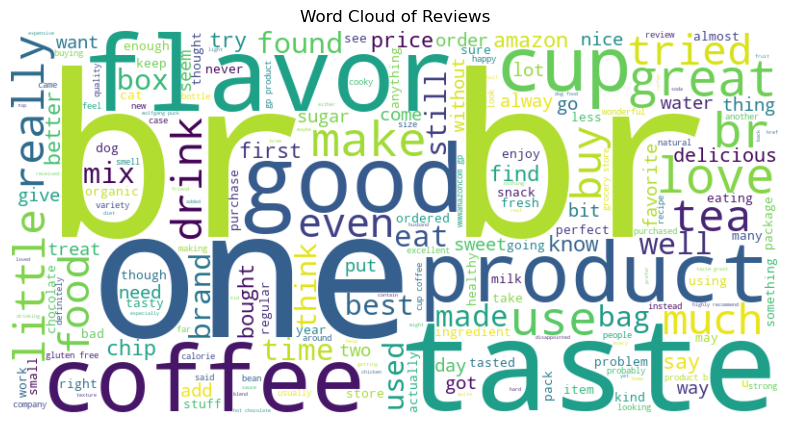

In [ ]:
#word cloud of reviews 
from wordcloud import WordCloud
import matplotlib. pyplot as plt

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color="white").generate(" ".join(all_words))

plt.figure(figsize=(10, 5))
plt. imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Reviews")
plt.show()

In [ ]:
all_words_pos = positive_df["Text"].loc[:10000].apply(get_words).sum()
word_counts=Counter(all_words)
print(word_counts.most_common(10))

[('br', 7352), ('like', 3183), ('coffee', 2868), ('good', 2799), ('flavor', 2643), ('great', 2579), ('taste', 2547), ('one', 2340), ('product', 2276), ('love', 2221)]


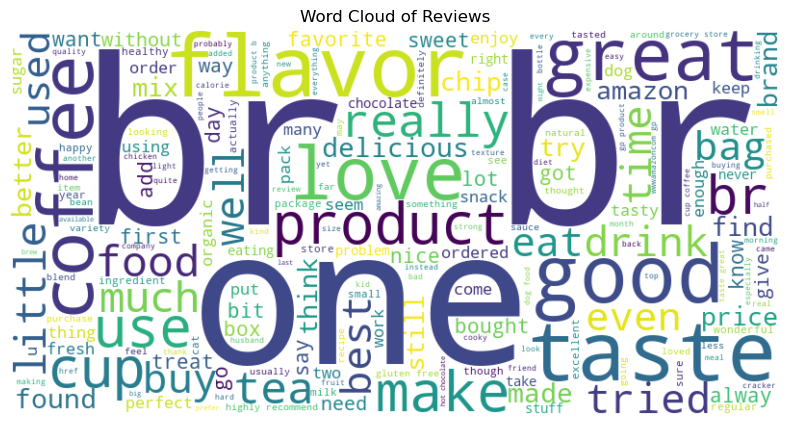

In [ ]:
from wordcloud import WordCloud
import matplotlib. pyplot as plt

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color="white").generate(" ".join(all_words))

plt.figure(figsize=(10, 5))
plt. imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Reviews")
plt.show()

In [ ]:
all_words_neg = negative_df["Text"].loc[:10000].apply(get_words).sum()
word_counts=Counter(all_words_neg)
print(word_counts.most_common(10))

[('br', 2009), ('like', 840), ('product', 759), ('taste', 728), ('coffee', 557), ('one', 552), ('flavor', 508), ('would', 493), ('good', 404), ('food', 395)]


In [ ]:
from collections import Counter
import re
# function to clean text and extract words
def get_words(text):# convert to lowercase
  text = re.sub(r"[^a-zA-Z\s]", "", text)
  words = text.split()
  return words
all_words = data["Summary"].loc[:10000].apply(get_words).sum()
word_counts=Counter(all_words)
print(word_counts.most_common(10))

[('great', 1358), ('good', 990), ('best', 623), ('coffee', 585), ('love', 531), ('taste', 427), ('product', 355), ('delicious', 303), ('flavor', 286), ('tea', 262)]


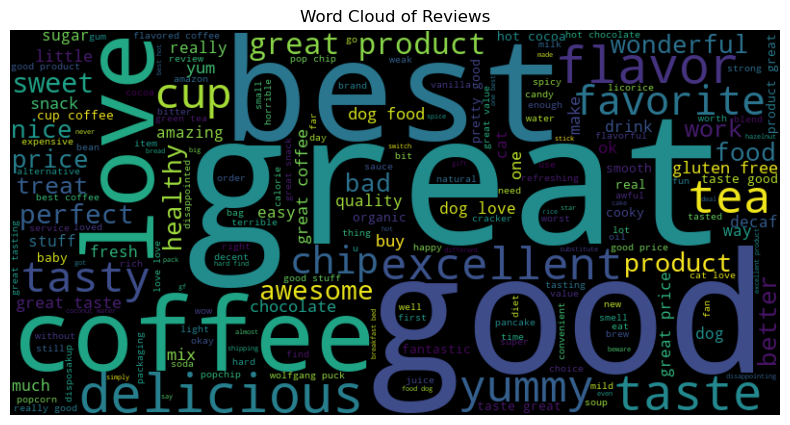

In [ ]:
## word cloud for positive reviews
from wordcloud import WordCloud
import matplotlib. pyplot as plt

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color="black").generate(" ".join(all_words))

plt.figure(figsize=(10, 5))
plt. imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Reviews")
plt.show()

In [41]:
data.to_csv("Clean_file.csv")